In [1]:
import numpy as np
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import DataLoader,TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, TfidfTransformer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, accuracy_score,precision_score,recall_score,f1_score, ConfusionMatrixDisplay, confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.ensemble import VotingClassifier
import matplotlib.pyplot as plt
from collections import Counter
import tiktoken
import seaborn as sns
from spacy.lang.fr.stop_words import STOP_WORDS as fr_stop
from spacy.lang.en.stop_words import STOP_WORDS as en_stop
from nltk import word_tokenize          
from nltk.stem import WordNetLemmatizer 
from utils import train_test
from gensim.models import Word2Vec

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [3]:
class RNNClassfier(nn.Module):
    def __init__(self, input_dim,hidden_dim,num_layers=1,bidrectionnal=False,dropout=0.2, num_classes=6):
        super(RNNClassfier,self).__init__()
        self.rnn = nn.RNN(input_size=input_dim,
                          hidden_size=hidden_dim,
                          num_layers= num_layers,
                          bidirectional=bidrectionnal,
                          dropout=dropout if num_layers >1 else 0)
        self.fc = nn.Linear(hidden_dim,num_classes)

    def forward(self,x):
        output,hidden = self.rnn(x)

        last_output = output[:,-1,:]
        out = self.fc(last_output)
        return out
class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.001):
        """
        patience: Nombre d'époques à attendre avant d'arrêter si pas d'amélioration.
        min_delta: Amélioration minimale considérée comme significative.
        """
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float('inf')
        self.counter = 0

    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0 
        else:
            self.counter += 1 
        return self.counter >= self.patience


In [4]:
def accuracy(y_pred, y_true):
    _, predicted = torch.max(y_pred, 1)
    correct = (predicted == y_true).sum().item()
    accuracy = correct / y_true.size(0)
    return accuracy

def precision(y_pred, y_true, num_classes):
    _, predicted = torch.max(y_pred, 1)
    precisions = []
    
    for i in range(num_classes):
        true_positive = ((predicted == i) & (y_true == i)).sum().item()
        false_positive = ((predicted == i) & (y_true != i)).sum().item()
        precision = true_positive / (true_positive + false_positive) if (true_positive + false_positive) > 0 else 0
        precisions.append(precision)
    
    return sum(precisions) / num_classes  # Moyenne des précisions

def recall(y_pred, y_true, num_classes):
    _, predicted = torch.max(y_pred, 1)
    recalls = []
    
    for i in range(num_classes):
        true_positive = ((predicted == i) & (y_true == i)).sum().item()
        false_negative = ((predicted != i) & (y_true == i)).sum().item()
        recall = true_positive / (true_positive + false_negative) if (true_positive + false_negative) > 0 else 0
        recalls.append(recall)
    
    return sum(recalls) / num_classes  # Moyenne des rappels

def f1_score(y_pred, y_true, num_classes):
    p = precision(y_pred, y_true, num_classes)
    r = recall(y_pred, y_true, num_classes)
    f1 = 2 * (p * r) / (p + r) if (p + r) > 0 else 0
    return f1


In [5]:
def train(dataloader,model,loss_fnc,optimizer,epoch):
    model.train()
    for batch_size,(X,y) in enumerate(dataloader):
        X.to(device)
        y.to(device)
        y_pred = model(X)
        loss = loss_fnc(y_pred,y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Step: {epoch} Train Loss: {loss.item():.4f}")
    return loss


def test(dataloader, model, loss_fnc):
    model.eval()
    all_preds = []
    all_targets = []
    total_loss = 0

    with torch.no_grad():
        for X, y in dataloader:
            X.to(device)
            y.to(device)
            y_pred = model(X)
            loss = loss_fnc(y_pred, y)
            total_loss += loss.item()

            all_preds.append(y_pred)
            all_targets.append(y)

    # Concaténation finale (par batchs, donc plus petit)
    all_preds = torch.cat(all_preds, dim=0)
    all_targets = torch.cat(all_targets, dim=0)

    print(f"Test error \nAccuracy: {accuracy(all_preds, all_targets)}\n"
          f"Precision: {precision(all_preds, all_targets, 6)}\n"
          f"Recall: {recall(all_preds, all_targets, 6)}\n"
          f"F1-score: {f1_score(all_preds, all_targets, 6)}\n"
          f"Loss: {total_loss / len(dataloader):.4f}")

# Processing data

In [6]:
# Variable
percentage_genre_to_keep = 25


In [7]:
df = pd.read_csv("../data/MovieDataThread.csv")
index_drop = df.loc[df['imdb_id'].isnull()].index
df = df.drop(index=index_drop)
df = df.drop(columns=['imdb_id'])
df_filtered = pd.concat([df[['Script','Title']],df.filter(like='imdb_')],axis=1)


In [8]:
df_filtered["genre_count"] = df_filtered.filter(regex='^imdb_(?!id$)').count(axis=1)
df_filtered_one_genre = df_filtered.loc[df_filtered['genre_count'] == 1]
print(df_filtered_one_genre.shape)
df_filtered_one_genre.head()

(8753, 31)


,Script,Title,imdb_action,imdb_adventure,imdb_animation,imdb_biography,imdb_comedy,imdb_crime,imdb_documentary,imdb_drama,...,imdb_romance,imdb_sci-fi,imdb_short,imdb_sport,imdb_talk-show,imdb_thriller,imdb_war,imdb_western,imdb_adult,genre_count
0,So what's goin' on?\n Where's my brother?\n So...,Beyond the Dunwich Horror (2008),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
3,"Like this?\n Good.\n Okay, that's good.\n Righ...",Beyond the Gates (2016),NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
5,1\n Beyond the hills\n Stay there!\n Voichita!...,Beyond the Hills (2012),NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
23,"Sir, this place is so dusty.\n Hmm.\n Your cho...",Bhagavan Dasante Ramrajyam (2023),NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
28,"1\n 'Ronapura's own living God, Bhairathi\n Ra...",Bhairathi Ranagal (2024),NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1


In [9]:
df_filtered_one_genre['filtered_genre'] = df_filtered_one_genre.apply(lambda row: next(iter([col for col in df_filtered_one_genre.columns if "imdb" in col and row[col] == 1.0 ]), 'unknown'), axis=1)
df_filtered_one_genre['filtered_genre']


C:\Users\letru\AppData\Local\Temp\ipykernel_5068\707917607.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered_one_genre['filtered_genre'] = df_filtered_one_genre.apply(lambda row: next(iter([col for col in df_filtered_one_genre.columns if "imdb" in col and row[col] == 1.0 ]), 'unknown'), axis=1)


0             imdb_horror
3              imdb_drama
5              imdb_drama
23             imdb_drama
28             imdb_drama
               ...       
38115          imdb_drama
38123    imdb_documentary
38125          imdb_drama
38133      imdb_adventure
38134          imdb_drama
Name: filtered_genre, Length: 8753, dtype: object

In [10]:
df_filtered_one_genre['filtered_genre'] = df_filtered_one_genre.apply(lambda row: next(iter([col for col in df_filtered_one_genre.columns if "imdb" in col and row[col] == 1.0 ]), 'unknown'), axis=1)
df_filtered_one_genre['filtered_genre']


C:\Users\letru\AppData\Local\Temp\ipykernel_5068\707917607.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered_one_genre['filtered_genre'] = df_filtered_one_genre.apply(lambda row: next(iter([col for col in df_filtered_one_genre.columns if "imdb" in col and row[col] == 1.0 ]), 'unknown'), axis=1)


0             imdb_horror
3              imdb_drama
5              imdb_drama
23             imdb_drama
28             imdb_drama
               ...       
38115          imdb_drama
38123    imdb_documentary
38125          imdb_drama
38133      imdb_adventure
38134          imdb_drama
Name: filtered_genre, Length: 8753, dtype: object

In [11]:
df_filtered_one_genre['filtered_genre'].value_counts()


filtered_genre
imdb_drama          2948
imdb_comedy         1622
imdb_documentary    1301
imdb_horror          944
imdb_thriller        643
imdb_romance         262
imdb_action          242
imdb_western         112
imdb_family          112
imdb_sci-fi           79
imdb_crime            61
imdb_animation        56
imdb_talk-show        51
imdb_music            50
imdb_short            49
imdb_mystery          49
imdb_adventure        37
imdb_fantasy          27
imdb_reality-tv       21
imdb_musical          21
imdb_war              16
imdb_biography        16
imdb_sport            12
imdb_game-show         8
imdb_news              8
imdb_history           6
Name: count, dtype: int64

C:\Users\letru\AppData\Local\Temp\ipykernel_5068\3269823211.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Genre', data=df_counts, palette="viridis")


Text(0, 0.5, 'Genres')

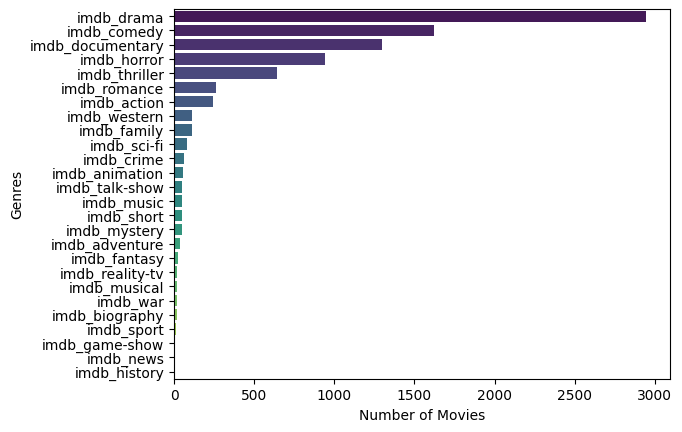

In [12]:

df_counts = df_filtered_one_genre['filtered_genre'].value_counts().reset_index()
df_counts.columns = ['Genre', 'Count']

sns.barplot(x='Count', y='Genre', data=df_counts, palette="viridis")

plt.xlabel('Number of Movies')
plt.ylabel('Genres')


In [13]:
number_genres = len(df_filtered_one_genre['filtered_genre'].unique())
counter = Counter(df_filtered_one_genre['filtered_genre'])

In [14]:
sorted_list = sorted(counter.items(),reverse=True , key=lambda genre : genre[1])[: int(number_genres * (percentage_genre_to_keep / 100))]

for genre,number in sorted_list:
    print(f"Genre: {genre}, number of samples: {number}")

genre_to_keep = [genre for genre,_ in sorted_list]
genre_to_keep

Genre: imdb_drama, number of samples: 2948
Genre: imdb_comedy, number of samples: 1622
Genre: imdb_documentary, number of samples: 1301
Genre: imdb_horror, number of samples: 944
Genre: imdb_thriller, number of samples: 643
Genre: imdb_romance, number of samples: 262


['imdb_drama',
 'imdb_comedy',
 'imdb_documentary',
 'imdb_horror',
 'imdb_thriller',
 'imdb_romance']

In [15]:
columns_to_keep = ['Script','filtered_genre']

df_filtered_one_genre_to_train = df_filtered_one_genre.loc[df_filtered_one_genre['filtered_genre'].isin(genre_to_keep)]
df_filtered_one_genre_to_train = df_filtered_one_genre_to_train[columns_to_keep].reset_index(drop=True)


# Training and test

In [16]:
test_size = 0.2       
random_state=42

In [17]:
X_train,X_test , y_train,y_test = train_test_split(df_filtered_one_genre_to_train['Script'],df_filtered_one_genre_to_train['filtered_genre'],test_size=test_size,random_state=random_state)

In [19]:
X_train_token = [word_tokenize(script) for script in X_train]
X_test_token = [word_tokenize(script) for script in X_test]

In [20]:
word2vec = Word2Vec(sentences=X_train_token, vector_size=300, window=5, min_count=2, workers=4)

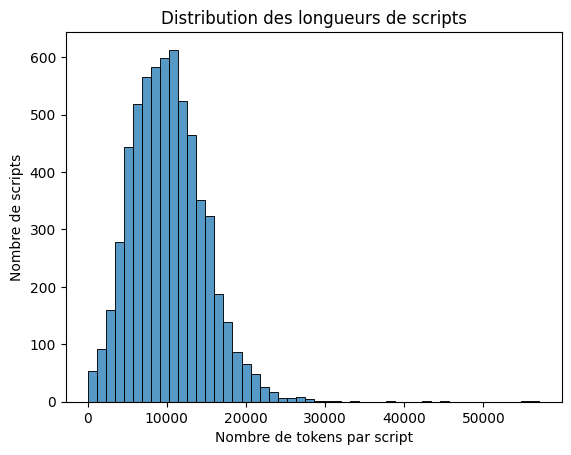

Taille max des séquences choisie : 15972


In [21]:
script_lengths = [len(tokens) for tokens in X_train_token]

import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(script_lengths, bins=50)
plt.xlabel("Nombre de tokens par script")
plt.ylabel("Nombre de scripts")
plt.title("Distribution des longueurs de scripts")
plt.show()

max_seq_len = int(np.percentile(script_lengths, 90))  # ou 95 si t'es généreux

print(f"Taille max des séquences choisie : {max_seq_len}")

In [22]:
from torch.utils.data import Dataset
class ScriptDatasetLazy(Dataset):
    def __init__(self, tokenized_data, labels, model, max_len=500, dim=300):
        self.data = tokenized_data
        self.labels = labels
        self.model = model
        self.max_len = max_len
        self.dim = dim

    def vectorize_and_pad(self, sentence):
        vecs = [self.model.wv[word] for word in sentence if word in self.model.wv]
        if not vecs:
            vecs = [np.zeros(self.dim)]
        vecs = vecs[:self.max_len]
        pad_len = self.max_len - len(vecs)
        if pad_len > 0:
            vecs += [np.zeros(self.dim)] * pad_len
        return np.array(vecs, dtype=np.float32)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        vec = self.vectorize_and_pad(self.data[idx])
        label = self.labels[idx]
        return torch.tensor(vec, dtype=torch.float32), torch.tensor(label, dtype=torch.long)


In [23]:
encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train)
y_test_encoded = encoder.transform(y_test)


y_tensor_train = torch.tensor(y_train_encoded,dtype=torch.long).view(-1)
y_tensor_test = torch.tensor(y_test_encoded,dtype=torch.long).view(-1)


train_dataset = ScriptDatasetLazy(X_train_token, y_train_encoded, word2vec, max_len=max_seq_len)
test_dataset  = ScriptDatasetLazy(X_test_token,  y_test_encoded, word2vec, max_len=max_seq_len)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

In [24]:
model = RNNClassfier(300,hidden_dim=128,num_layers=2)
early_stopping = EarlyStopping(patience=5, min_delta=0.0001)
loss_fnc = nn.CrossEntropyLoss()
optimizer_adam = torch.optim.Adam(model.parameters(),lr=0.001)
epochs = 10
for epoch in range(epochs):
    print(f"epoch: {epoch}")
    loss = train(train_loader,model,loss_fnc,optimizer_adam,epoch)
    if early_stopping(loss):
        print(f"Early stopping triggered at epoch {epoch} ")
        break

test(test_loader,model,loss_fnc)

epoch: 0
Step: 0 Train Loss: 1.5648
epoch: 1
Step: 1 Train Loss: 1.5607
epoch: 2
Step: 2 Train Loss: 1.5480
epoch: 3
Step: 3 Train Loss: 1.6042
epoch: 4
Step: 4 Train Loss: 1.4854
epoch: 5
Step: 5 Train Loss: 1.6666
epoch: 6
Step: 6 Train Loss: 1.5156
epoch: 7
Step: 7 Train Loss: 1.8589
epoch: 8
Step: 8 Train Loss: 1.6268
epoch: 9
Step: 9 Train Loss: 1.4319
Test error 
Accuracy: 0.39896373056994816
Precision: 0.22597288597615497
Recall: 0.18126693115702022
F1-score: 0.20116604439097713
Loss: 1.5788
